In [1]:
from asammdf import MDF 
import cantools 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go 
from plotly.subplots import make_subplots

In [2]:

db = cantools.database.load_file(r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\obd2-pack-v5\obd2-dbc\CSS-Electronics-11-bit-OBD2-v2.2.dbc")

print("=== Messages in DBC ===")
for message in db.messages:
    print (f"\n Message : {message.name}")
    print (f"CAN ID : {hex(message.frame_id)}")
    print (f"Length : {message.length} bytes")

    for signal in message.signals:
        print(f"\nSignal : '{signal.name}'")
        print(f"Start bit : {signal.start}")
        print(f"Bit length : {signal.length}")
        print(f"Unit : '{signal.unit}'")
        print(f"Scale/Offset : {signal.scale} / {signal.offset}")

=== Messages in DBC ===

 Message : OBD2
CAN ID : 0x7e8
Length : 8 bytes

Signal : 'Length'
Start bit : 7
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'Response'
Start bit : 15
Bit length : 4
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'Service'
Start bit : 11
Bit length : 4
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID'
Start bit : 23
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S02PID'
Start bit : 23
Bit length : 8
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID00_PIDsSupported_01_20'
Start bit : 31
Bit length : 32
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID01_MonitorStatus'
Start bit : 31
Bit length : 32
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID02_FreezeDTC'
Start bit : 31
Bit length : 16
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID03_FuelSystemStatus'
Start bit : 31
Bit length : 16
Unit : 'None'
Scale/Offset : 1 / 0

Signal : 'S01PID04_CalcEngineLoad'
Start bit : 31
Bit length : 8
Unit : '%'
Scale/Offset : 0.39

In [3]:
mdf = MDF(r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\obd2-pack-v5\obd2-sample-data\BMW\00000001.MF4")

raw_df = mdf.to_dataframe(
    channels=[
        'CAN_DataFrame.ID',
        'CAN_DataFrame.DataBytes',
        'CAN_DataFrame.DataLength',
        'CAN_DataFrame.Dir',         # Tx or Rx
        'CAN_DataFrame.BusChannel',  # which CAN port
    ]
)
raw_df.columns = ["Bus Channel", "ID", "DataLength", "DataBytes", "Direction"]

print("=== Raw DataFrame Info ===")
print(f"Total frames : {len(raw_df)}")
print(f"Columns      : {list(raw_df.columns)}")
print(f"Time range   : {raw_df.index[0]:.3f}s → {raw_df.index[-1]:.3f}s")
print()

OBD2_ID = 0x7E8  
obd2_df = raw_df[raw_df['ID'] == OBD2_ID].copy()

print(f"Total frames    : {len(raw_df)}")
print(f"OBD2 frames     : {len(obd2_df)}")
print()

#Decoration 
print("=== First 10 Raw OBD2 Frames ===")
print(f"{'Timestamp':>12}   B0    B1    B2    B3    B4    B5    B6    B7")
print(f"{'':>12}   Len   Mode  PID   A     B     C     D     ")
print("-" * 75)

#Converting the databytes into hex code 
for timestamp, row in obd2_df.head(10).iterrows():
    hex_str = '  '.join(f'{b:02X}' for b in row['DataBytes'])
    print(f"{timestamp:>12.5f}s   {hex_str}")

=== Raw DataFrame Info ===
Total frames : 898081
Columns      : ['Bus Channel', 'ID', 'DataLength', 'DataBytes', 'Direction']
Time range   : 0.000s → 1328.113s

Total frames    : 898081
OBD2 frames     : 27521

=== First 10 Raw OBD2 Frames ===
   Timestamp   B0    B1    B2    B3    B4    B5    B6    B7
               Len   Mode  PID   A     B     C     D     
---------------------------------------------------------------------------
     0.02960s   03  41  05  3A  00  00  00  00
     0.09115s   04  41  0C  12  68  00  00  00
     0.11150s   03  41  0D  00  00  00  00  00
     0.13200s   04  41  10  01  D3  00  00  00
     0.15295s   03  41  11  2F  00  00  00  00
     0.29180s   04  41  0C  12  23  00  00  00
     0.31230s   03  41  0D  00  00  00  00  00
     0.32865s   04  41  10  01  DF  00  00  00
     0.34915s   03  41  11  2F  00  00  00  00
     0.49255s   04  41  0C  12  0A  00  00  00


In [4]:
obd2_df

,Bus Channel,ID,DataLength,DataBytes,Direction
timestamps,,,,,
0.02960,1,2024,8,"[3, 65, 5, 58, 0, 0, 0, 0]",0
0.09115,1,2024,8,"[4, 65, 12, 18, 104, 0, 0, 0]",0
0.11150,1,2024,8,"[3, 65, 13, 0, 0, 0, 0, 0]",0
0.13200,1,2024,8,"[4, 65, 16, 1, 211, 0, 0, 0]",0
0.15295,1,2024,8,"[3, 65, 17, 47, 0, 0, 0, 0]",0
...,...,...,...,...,...
1327.84645,1,2024,8,"[3, 65, 17, 47, 0, 0, 0, 0]",0
1327.98605,1,2024,8,"[4, 65, 12, 0, 0, 0, 0, 0]",0
1328.00630,1,2024,8,"[3, 65, 13, 0, 0, 0, 0, 0]",0


In [5]:
decoded_records = []
for timestamp, row in obd2_df.iterrows():
    raw_bytes = row["DataBytes"]
    raw_bytes = bytes(raw_bytes)

    try: 
        decoded = db.decode_message(frame_id_or_name=0x7E8, data = raw_bytes, decode_choices=False)
        
        decoded['timestamp'] = timestamp
        decoded_records.append(decoded)

    except Exception as e: 
        print (f"Could not decode frame at {timestamp:.4f}s : {e}")
        pass

print(f"Total frames    : {len(obd2_df)}")
print(f"Decoded frames  : {len(decoded_records)}")
print()

decoded_df = pd.DataFrame(decoded_records)
decoded_df = decoded_df.set_index("timestamp")

print (f"Shape : {decoded_df.shape}")
print (f"Decoded Columns : {list(decoded_df.columns)}")
print()
print(decoded_df.head(10))

Total frames    : 27521
Decoded frames  : 27521

Shape : (27521, 11)
Decoded Columns : ['Length', 'Response', 'Service', 'S01PID', 'S01PID05_EngineCoolantTemp', 'S01PID0C_EngineRPM', 'S01PID0D_VehicleSpeed', 'S01PID10_MAFAirFlowRate', 'S01PID11_ThrottlePosition', 'S01PID00_PIDsSupported_01_20', 'S01PID40_PIDsSupported_41_60']

           Length  Response  Service  S01PID  S01PID05_EngineCoolantTemp  \
timestamp                                                                  
0.02960         3         4        1       5                        18.0   
0.09115         4         4        1      12                         NaN   
0.11150         3         4        1      13                         NaN   
0.13200         4         4        1      16                         NaN   
0.15295         3         4        1      17                         NaN   
0.29180         4         4        1      12                         NaN   
0.31230         3         4        1      13                   

In [6]:
id_counts = raw_df['ID'].value_counts()

print("=== CAN IDs in file (decimal → hex : frame count) ===")
for dec_id, count in id_counts.items():
    print(f"  {dec_id:>6} >> {hex(dec_id):>8}  :  {count} frames")

=== CAN IDs in file (decimal → hex : frame count) ===
     176 >>     0xb0  :  131885 frames
     178 >>     0xb2  :  131883 frames
     180 >>     0xb4  :  65929 frames
     608 >>    0x260  :  65245 frames
     610 >>    0x262  :  65243 frames
     725 >>    0x2d5  :  55977 frames
     708 >>    0x2c4  :  55975 frames
     548 >>    0x224  :  43967 frames
     547 >>    0x223  :  43942 frames
     710 >>    0x2c6  :  41536 frames
     705 >>    0x2c1  :  41528 frames
    2024 >>    0x7e8  :  27521 frames
     709 >>    0x2c5  :  27397 frames
     832 >>    0x340  :  27396 frames
     928 >>    0x3a0  :  13190 frames
    1090 >>    0x442  :  6907 frames
    1088 >>    0x440  :  6904 frames
    1568 >>    0x620  :  4420 frames
     951 >>    0x3b7  :  4398 frames
     916 >>    0x394  :  4349 frames
    1552 >>    0x610  :  2643 frames
     947 >>    0x3b3  :  2576 frames
    1600 >>    0x640  :  1675 frames
    1217 >>    0x4c1  :  1450 frames
    1219 >>    0x4c3  :  1419 frames
    

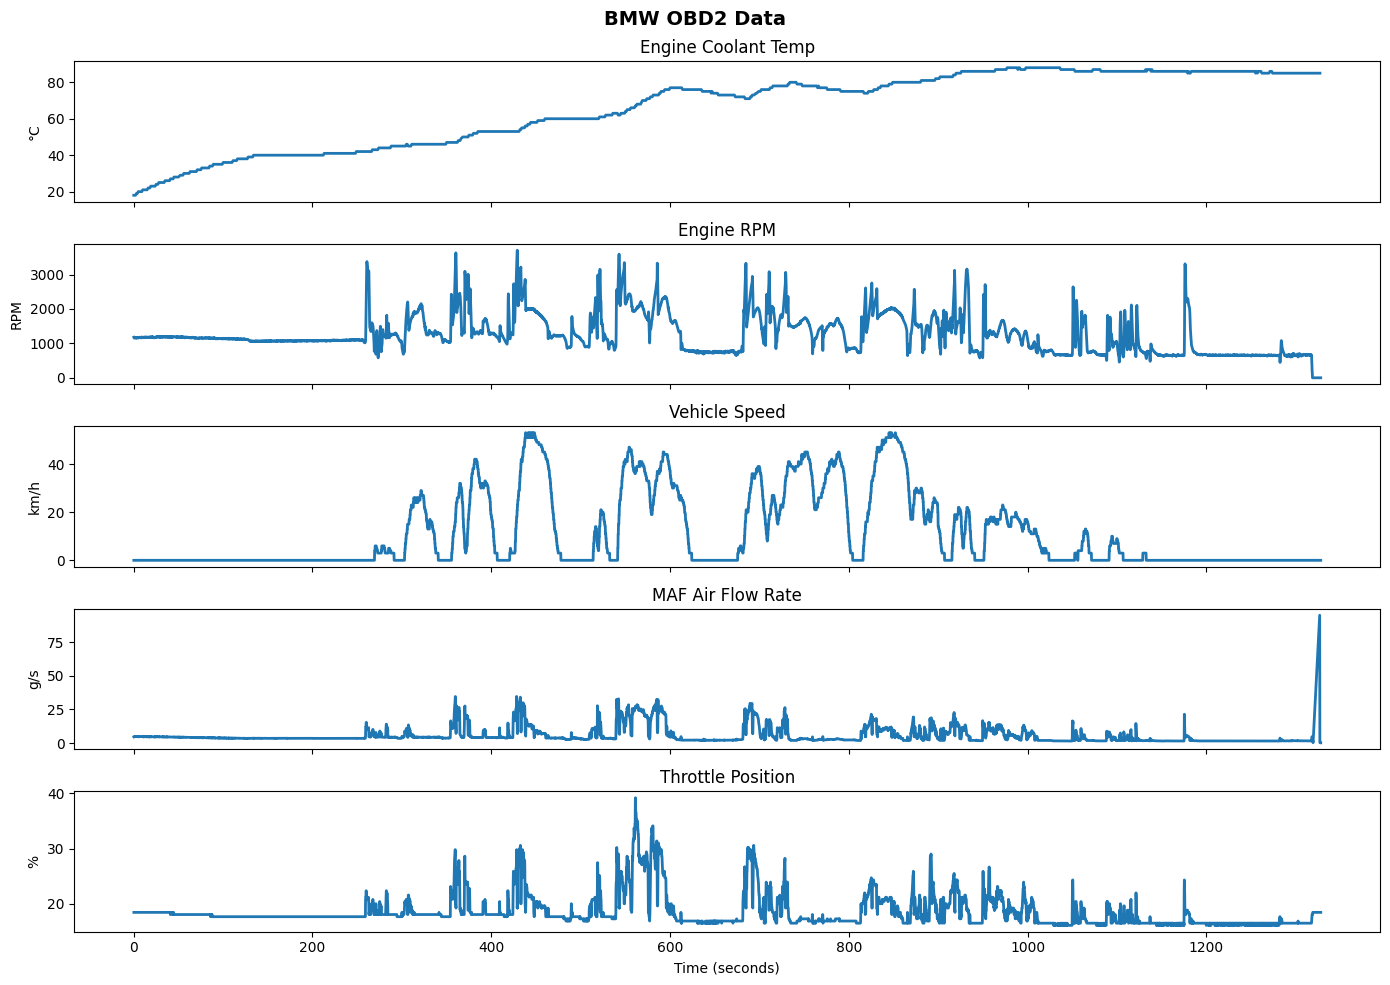

In [7]:
signals_to_plot = [
    'S01PID05_EngineCoolantTemp',
    'S01PID0C_EngineRPM',
    'S01PID0D_VehicleSpeed',
    'S01PID10_MAFAirFlowRate',
    'S01PID11_ThrottlePosition'
]

signal_series = {}
for signal in signals_to_plot: 
    series = decoded_df[signal].dropna()
    signal_series[signal] = series
    # print(f"{signal:45} -- {len(series)} samples")

print()

#Creating subplots 

fig, axes = plt.subplots(
    nrows=len(signals_to_plot),
    ncols = 1,
    figsize = (14,10),
    sharex = True
)

fig.suptitle("BMW OBD2 Data", fontsize = 14, fontweight = "bold")
plt.rcParams['axes.grid'] = True

units = {
    'S01PID05_EngineCoolantTemp' : '°C',
    'S01PID0C_EngineRPM'         : 'RPM',
    'S01PID0D_VehicleSpeed'      : 'km/h',
    'S01PID10_MAFAirFlowRate'    : 'g/s',
    'S01PID11_ThrottlePosition'  : '%'
}

titles = {
    'S01PID05_EngineCoolantTemp' : 'Engine Coolant Temp',
    'S01PID0C_EngineRPM'         : 'Engine RPM',
    'S01PID0D_VehicleSpeed'      : 'Vehicle Speed',
    'S01PID10_MAFAirFlowRate'    : 'MAF Air Flow Rate',
    'S01PID11_ThrottlePosition'  : 'Throttle Position'
}

for i, signal in enumerate(signals_to_plot):
    ax = axes[i]
    series = signal_series[signal]

    ax.plot(series.index,series.values, linewidth = 2)
    ax.set_ylabel(units[signal])
    ax.set_title(titles[signal])

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

In [8]:
#Quick Stats of the decoeded dataframe with .describe()

for sig_name, unit in units.items():
    signal_stats = decoded_df[sig_name].dropna().describe()
    
    print (signal_stats)
    print()

count    1312.000000
mean       66.108232
std        19.999745
min        18.000000
25%        46.000000
50%        75.000000
75%        86.000000
max        88.000000
Name: S01PID05_EngineCoolantTemp, dtype: float64

count    6544.000000
mean     1266.790763
std       549.713675
min         0.000000
25%       795.250000
50%      1151.875000
75%      1562.687500
max      3705.250000
Name: S01PID0C_EngineRPM, dtype: float64

count    6553.000000
mean       11.309171
std        15.658782
min         0.000000
25%         0.000000
50%         0.000000
75%        21.000000
max        53.000000
Name: S01PID0D_VehicleSpeed, dtype: float64

count    6559.000000
mean        5.725036
std         5.954419
min         0.210000
25%         2.170000
50%         3.600000
75%         5.390000
max        95.030000
Name: S01PID10_MAFAirFlowRate, dtype: float64

count    6551.000000
mean       18.580638
std         3.009352
min        16.078560
25%        16.862880
50%        17.647200
75%        18.8236

In [9]:
#Saving the decoded dataframe as a CSV 

output_path = r"C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\Decoded files\BMW_obd2_decoded.csv"

decoded_df.to_csv(output_path)

print(f"Saved to : {output_path}")
print (f"Number of rows: {len(decoded_df)}")
print (f"Columns : {list(decoded_df.columns)}")

Saved to : C:\Users\dell\Desktop\MBGP Mentoring\Programming\Excel Data\Decoded files\BMW_obd2_decoded.csv
Number of rows: 27521
Columns : ['Length', 'Response', 'Service', 'S01PID', 'S01PID05_EngineCoolantTemp', 'S01PID0C_EngineRPM', 'S01PID0D_VehicleSpeed', 'S01PID10_MAFAirFlowRate', 'S01PID11_ThrottlePosition', 'S01PID00_PIDsSupported_01_20', 'S01PID40_PIDsSupported_41_60']


In [21]:
fig = make_subplots(
    rows = 5, 
    cols= 1, 
    shared_xaxes= False, 
    subplot_titles= ('Engine Coolant Temp (°C)', 
    'Engine RPM (RPM)', 
    'Vehicle Speed (km/h)', 
    'MAF Air Flow Rate (g/s)',
    'Throttle Position (%)'), 
    vertical_spacing= 0.1, 
)
signal_config = [
    ('S01PID05_EngineCoolantTemp', 1, 'red'),  
    ('S01PID0C_EngineRPM',         2, 'blue'),  
    ('S01PID0D_VehicleSpeed',      3, 'green'),  
    ('S01PID10_MAFAirFlowRate',    4, 'yellow'),  
    ('S01PID11_ThrottlePosition',  5, 'purple'),  
]

for sig_name, row, colour in signal_config:
    sig_data = decoded_df[sig_name].dropna()

    fig.add_trace(go.Scatter(
        x = sig_data.index, 
        y = sig_data.values, 
        mode = 'lines', 
        name = sig_name, 
        line = dict(color = colour, width = 1),
        showlegend= True
    ), 
    row = row, 
    col = 1 )

fig.update_layout( 
    title = "BMW OBD2 Plot (interactive)", 
    height = 900, 
    width = 1200, 
    plot_bgcolor = "white",
    paper_bgcolor = "white", 
    showlegend = True
)

fig.update_xaxes(title_text = "Time (seconds)", row = 5, col = 1)
fig.update_xaxes(showline=True, linewidth=0.5, linecolor='black', gridcolor = "lightgrey", gridwidth = 0.25)
fig.update_yaxes(showline=True, linewidth=0.5, linecolor='black', gridcolor = "lightgrey", gridwidth = 0.25, layer = "below traces" )

fig.show()